# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Student:**

Lopez Monterno Ivana Abigail

Jaramillo Rodriguez Leslie Citlalli

Salas Hernandez Camila Alexandra   
**Date:** 07/10/2026

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [ ]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for readability (optional)
plt.rcParams["figure.figsize"] = (10, 4)

# For reproducibility (only matters if you add noise later)
np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $$[-1,1]$$).

#Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

In [ ]:
# === TODO 1: DFS (Analysis) ===
'''
Razonamiento:
Primero se toma un periodo de la señal y
se calculan sus coeficientes de Fourier para identificar
sus componentes. Después, estos coeficientes se utilizan
para reconstruir la señal original. Finalmente, se compara
la señal original con la reconstruida mediante el RMSE para
comprobar qué tan cercana es la reconstrucción.
'''
def dfs(x):
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        basis = np.exp(-1j * 2 * np.pi * k * n / N)
        X[k] = (1.0 / N) * np.dot(x, basis)
    return X


# === TODO 2: Inverse DFS (Synthesis) ===
def idfs(X):
    X = np.asarray(X)
    N = len(X)
    k = np.arange(N)
    x_hat = np.zeros(N, dtype=complex)
    for n in range(N):
        basis = np.exp(1j * 2 * np.pi * k * n / N)
        x_hat[n] = np.sum(X * basis)
    return x_hat


def rmse(x, x_hat):
    x = np.asarray(x)
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2))

In [ ]:
# === TODO 3: Build the three signals (one period only) ===
# Periodos según el enunciado: N1=16, N2=32, N3=64

'''
Razonamiento:
Se construyen tres señales periódicas utilizando un solo periodo de cada una.
La primera es una señal cuadrada, la segunda es una señal triangular y la tercera
es una combinación de tres señales sinusoidales con diferentes frecuencias y amplitudes.
'''

# Signal A:
N1 = 16
n1 = np.arange(N1)
xA = np.where(n1 < N1 // 2, 1.0, -1.0)


N2 = 32
n2 = np.arange(N2)
xB = 1 - 2 * np.abs(n2 - N2 / 2) / (N2 / 2)


N3 = 64
n3 = np.arange(N3)
xC = (0.8 * np.cos(2 * np.pi * 1 / N3 * n3)
      + 0.4 * np.sin(2 * np.pi * 2 / N3 * n3 + 0.3)
      + 0.2 * np.cos(2 * np.pi * 3 / N3 * n3 - 0.8))

## Helper plotting template (use or modify)

You may use `plt.stem` for discrete plots.  
When plotting phase, you can use `np.angle(X)` (optionally `np.unwrap`).

**Note:** Small imaginary parts in `x_hat` may appear due to numerical precision.  
If so, compare against `np.real(x_hat)` and report that you took the real part.


Signal A (square): N=16, RMSE=3.025676e-15


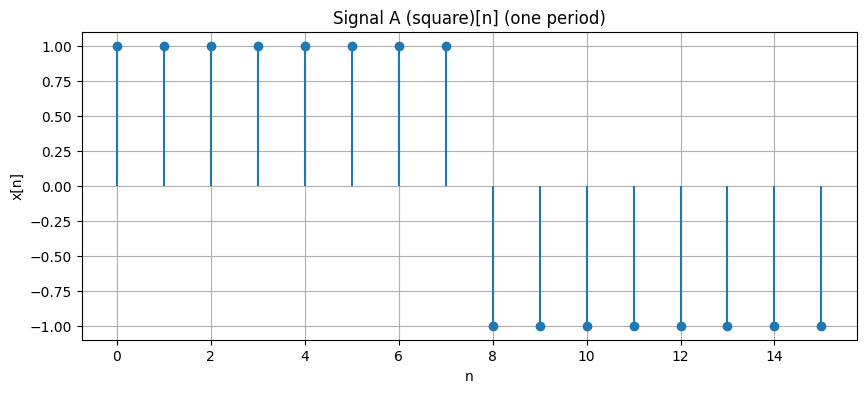

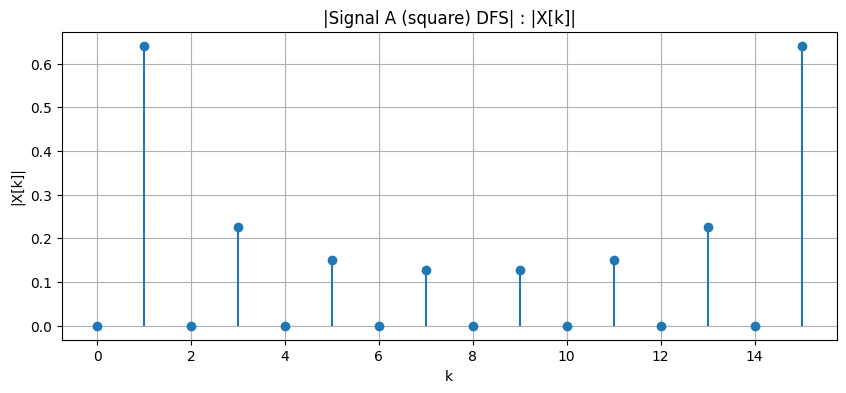

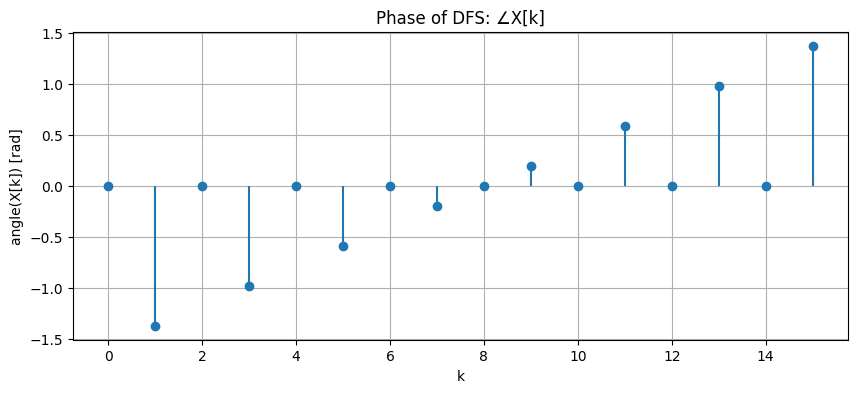

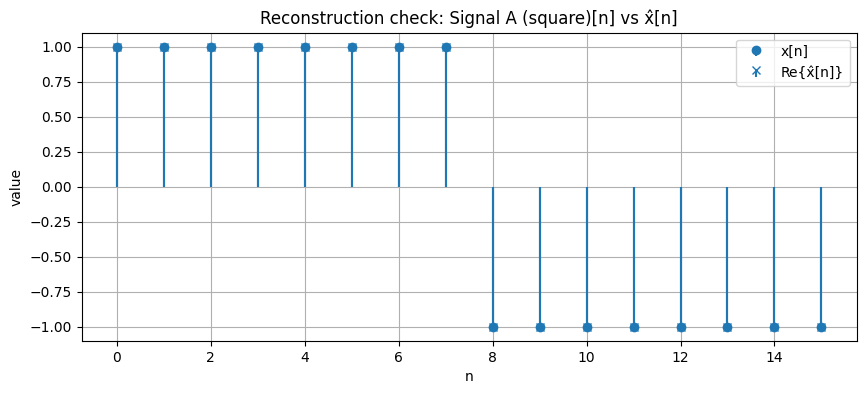

Signal B (triangle): N=32, RMSE=2.806586e-15


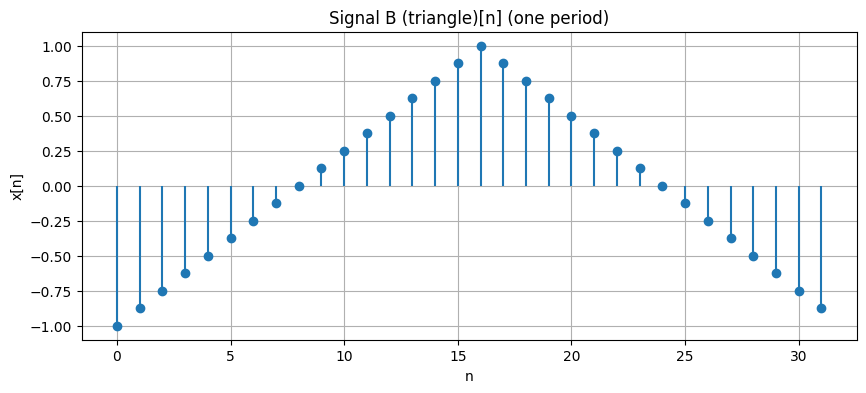

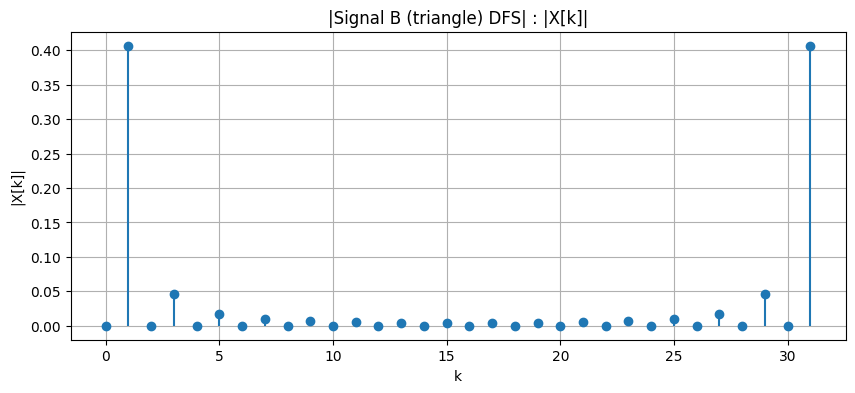

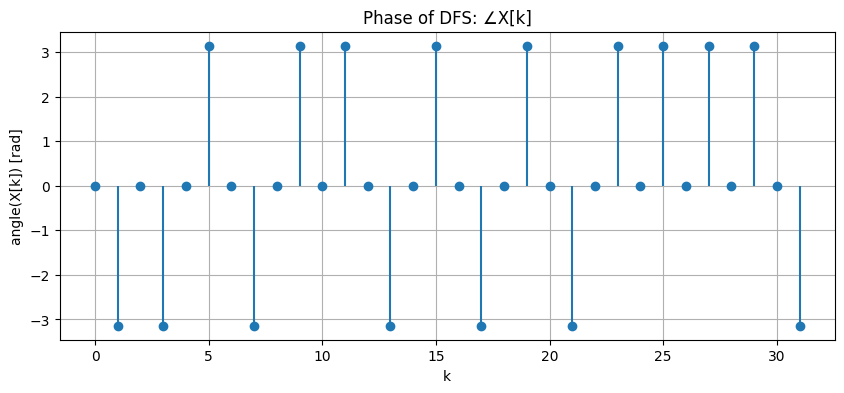

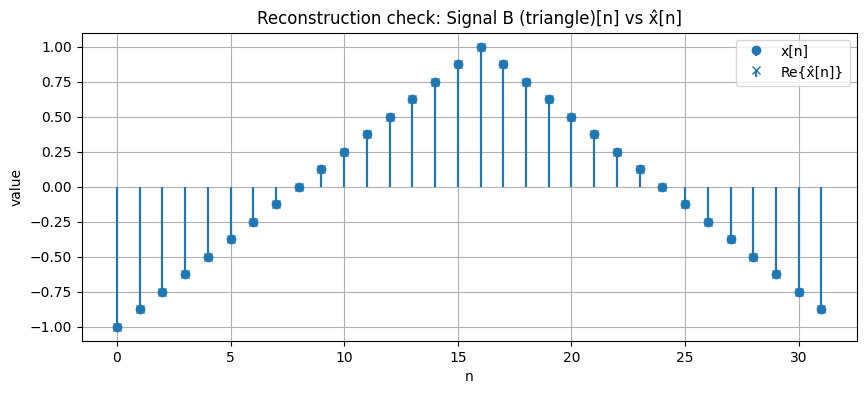

Signal C (sum of sinusoids): N=64, RMSE=7.338993e-15


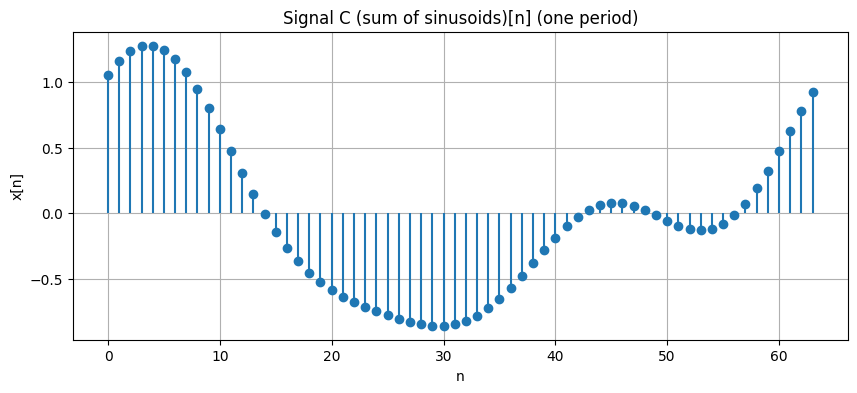

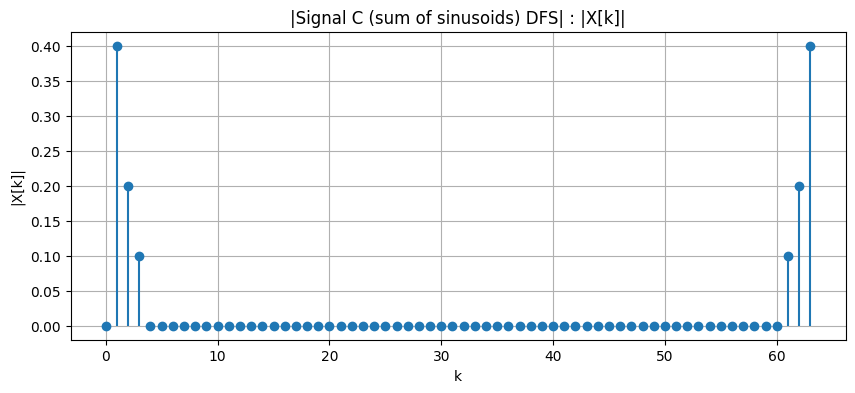

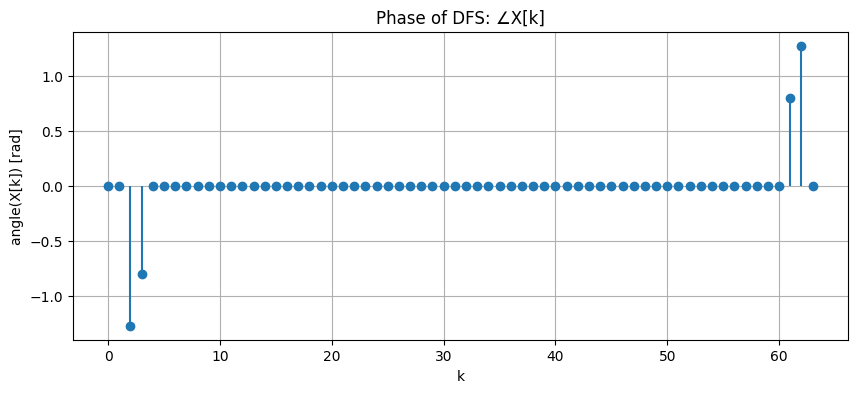

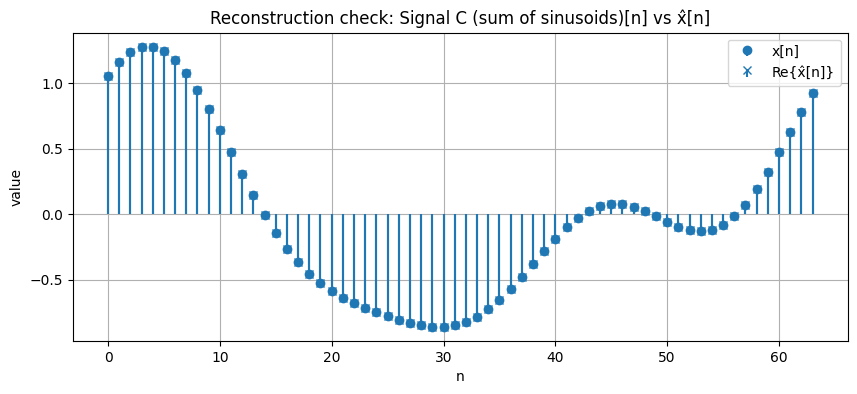

In [ ]:
def analyze_signal(x, name="x"):
    '''
Razonamiento:
Se analiza cada una de las tres señales utilizando la Serie de Fourier Discreta.
Para cada señal se obtienen sus coeficientes, se reconstruye la señal y se calcula
el error RMSE. Finalmente, se muestran las señales originales, sus espectros y la
comparación entre la señal original y la reconstruida para verificar los resultados.
'''
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)

    # --- DFS / IDFS ---
    X = dfs(x)
    x_hat = idfs(X)

    # --- Error ---
    e = rmse(x, x_hat)
    print(f"{name}: N={N}, RMSE={e:.6e}")

    # --- Plots: time domain ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ")
    plt.title(f"{name}[n] (one period)")
    plt.xlabel("n"); plt.ylabel("x[n]")
    plt.grid(True)
    plt.show()

    # --- Plots: magnitude spectrum ---
    k = np.arange(N)
    plt.figure()
    plt.stem(k, np.abs(X), basefmt=" ")
    plt.title(f"|{name} DFS| : |X[k]|")
    plt.xlabel("k"); plt.ylabel("|X[k]|")
    plt.grid(True)
    plt.show()

    # --- Plots: phase spectrum ---
    plt.figure()
    # La fase de coeficientes ~0 es ruido numérico: se fija en 0 si |X[k]| < 1e-10
    phase = np.where(np.abs(X) > 1e-10, np.angle(X), 0.0)
    plt.stem(k, phase, basefmt=" ")
    plt.title(f"Phase of DFS: ∠X[k]")
    plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
    plt.grid(True)
    plt.show()

    # --- Plots: reconstruction ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ", markerfmt="o", label="x[n]")
    plt.stem(n, np.real(x_hat), basefmt=" ", markerfmt="x", label="Re{x̂[n]}")

    plt.title(f"Reconstruction check: {name}[n] vs x̂[n]")
    plt.xlabel("n"); plt.ylabel("value")
    plt.grid(True)
    plt.legend()
    plt.show()

    return X, x_hat


# === TODO 4: Run analysis for A, B, C ===

XA, xA_hat = analyze_signal(xA, name="Signal A (square)")
XB, xB_hat = analyze_signal(xB, name="Signal B (triangle)")
XC, xC_hat = analyze_signal(xC, name="Signal C (sum of sinusoids)")

## Short reflection


**Signal A (cuadrada, N=16).** Solo tienen energía los armónicos impares (k = 1, 3, 5, … y sus simétricos N−k); los pares valen cero. Los coeficientes decrecen lentamente (≈ 1/k): |X[1]| ≈ 0.64, |X[3]| ≈ 0.23, |X[5]| ≈ 0.15, por eso hacen falta muchos para representar bien los saltos. La fase es muy estructurada (±π/2, por la simetría impar de la señal respecto al origen). Si se conservan solo los M mayores, la reconstrucción presenta oscilaciones y sobreimpulso en las discontinuidades (fenómeno de Gibbs).

**Signal B (triangular, N=32).** También solo armónicos impares, pero decaen mucho más rápido (≈ 1/k²): |X[1]| ≈ 0.41, |X[3]| ≈ 0.046, |X[5]| ≈ 0.018. Con 2–3 pares de coeficientes (k = ±1, ±3) ya se aproxima muy bien. Como la señal es par respecto a n=0, los coeficientes son reales y la fase vale solo 0 o π. Truncar a los M mayores da una reconstrucción suave con error pequeño, sin Gibbs marcado, porque la señal es continua.

**Signal C (suma de senoides, N=64).** Solo 3 pares de coeficientes dominantes: k = 1, 2, 3 (y 63, 62, 61) con magnitudes 0.4, 0.2 y 0.1 (la mitad de las amplitudes 0.8, 0.4, 0.2, porque cada senoide se reparte entre k y N−k). El resto es ~0 (≈1e-16). La fase codifica los desfases de cada componente (≈ 0, −1.27 y −0.8 rad para k = 1, 2, 3) y es simétrica impar (∠X[N−k] = −∠X[k]) por ser la señal real. Con M = 6 coeficientes la reconstrucción es exacta.

**Error de reconstrucción.** En las tres señales el RMSE es del orden de 1e−15 (error de punto flotante), lo que confirma que dfs/idfs son pares inversos exactos. Las partes imaginarias de x̂[n] son despreciables y se graficó la parte real.
